In [2]:
import os
import zipfile
import tempfile
import shutil
import numpy as np
import trimesh
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import re

In [3]:
#pip install trimesh

In [5]:
zip = "KITTI-Sequence.zip"
temp_dir = tempfile.mkdtemp()

with zipfile.ZipFile(zip, 'r') as zip_ref:
    zip_ref.extractall(temp_dir)

pattern = re.compile(r"\d+_points\.obj$")
scan_files = []

for root, _, files in os.walk(temp_dir):
    for file in files:
        if pattern.match(file):
            full_path = os.path.join(root, file)
            scan_files.append(full_path)

scan_files = sorted(scan_files, key=lambda x: int(re.search(r'(\d+)_points\.obj$', x).group(1)))

In [6]:
scan_files

['/tmp/tmpjnmq9vhr/000000/000000_points.obj',
 '/tmp/tmpjnmq9vhr/000001/000001_points.obj',
 '/tmp/tmpjnmq9vhr/000002/000002_points.obj',
 '/tmp/tmpjnmq9vhr/000003/000003_points.obj',
 '/tmp/tmpjnmq9vhr/000004/000004_points.obj',
 '/tmp/tmpjnmq9vhr/000005/000005_points.obj',
 '/tmp/tmpjnmq9vhr/000006/000006_points.obj',
 '/tmp/tmpjnmq9vhr/000007/000007_points.obj',
 '/tmp/tmpjnmq9vhr/000008/000008_points.obj',
 '/tmp/tmpjnmq9vhr/000009/000009_points.obj',
 '/tmp/tmpjnmq9vhr/000010/000010_points.obj',
 '/tmp/tmpjnmq9vhr/000011/000011_points.obj',
 '/tmp/tmpjnmq9vhr/000012/000012_points.obj',
 '/tmp/tmpjnmq9vhr/000013/000013_points.obj',
 '/tmp/tmpjnmq9vhr/000014/000014_points.obj',
 '/tmp/tmpjnmq9vhr/000015/000015_points.obj',
 '/tmp/tmpjnmq9vhr/000016/000016_points.obj',
 '/tmp/tmpjnmq9vhr/000017/000017_points.obj',
 '/tmp/tmpjnmq9vhr/000018/000018_points.obj',
 '/tmp/tmpjnmq9vhr/000019/000019_points.obj',
 '/tmp/tmpjnmq9vhr/000020/000020_points.obj',
 '/tmp/tmpjnmq9vhr/000021/000021_p

In [9]:
arquivos_selecionados = scan_files[:4]

objetos = [trimesh.load(arquivo) for arquivo in arquivos_selecionados]

for i, obj in enumerate(objetos):
    print(f"\nArquivo {i}: {arquivos_selecionados[i]}")
    print(obj)


Arquivo 0: /tmp/tmpjnmq9vhr/000000/000000_points.obj
<trimesh.PointCloud(vertices.shape=(62553, 3))>

Arquivo 1: /tmp/tmpjnmq9vhr/000001/000001_points.obj
<trimesh.PointCloud(vertices.shape=(62340, 3))>

Arquivo 2: /tmp/tmpjnmq9vhr/000002/000002_points.obj
<trimesh.PointCloud(vertices.shape=(62138, 3))>

Arquivo 3: /tmp/tmpjnmq9vhr/000003/000003_points.obj
<trimesh.PointCloud(vertices.shape=(61833, 3))>


## Funções

In [4]:
def carrega_pontos(path):
    return trimesh.load(path).vertices

def transformacao(A, B):
    centroid_A = np.mean(A, axis=0)
    centroid_B = np.mean(B, axis=0)

    AA = A - centroid_A
    BB = B - centroid_B

    H = AA.T @ BB
    U, _, Vt = np.linalg.svd(H)
    R = Vt.T @ U.T

    if np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    t = centroid_B - R @ centroid_A

    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3] = t
    return T

def icp(A, B, iteracoes_max=20, tolerancia=1e-6):
    src = np.copy(A)
    erro_prev = float('inf')
    T_total = np.eye(4)

    for _ in range(iteracoes_max):
        tree = cKDTree(B)
        distancias, indices = tree.query(src)
        matched_B = B[indices]

        T = transformacao(src, matched_B)

        src_h = np.hstack((src, np.ones((src.shape[0], 1))))
        src = (T @ src_h.T).T[:, :3]
        T_total = T @ T_total

        erro_mean = np.mean(distancias)
        if np.abs(erro_prev - erro_mean) < tolerancia:
            break
        erro_prev = erro_mean

    return T_total

def trajetoria_estimada(scan_files):
    trajetoria = []
    poses = []

    scan_inicial = carrega_pontos(scan_files[0])
    poses.append(np.eye(4))
    trajetoria.append(poses[-1][:3, 3])

    for i in range(1, len(scan_files)):
        source = carrega_pontos(scan_files[i])
        target = carrega_pontos(scan_files[i - 1])

        T = icp(source, target)

        poses.append(poses[-1] @ T)
        trajetoria.append(poses[-1][:3, 3])
        print(f"Frame {i}: Transl = {poses[-1][:3, 3]}")

    return np.array(trajetoria), np.array(poses)

def plot_trajetoria(estimado, ground_truth):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')

    ax.plot(estimado[:, 0], estimado[:, 1], estimado[:, 2], label='Estimado - ICP')
    ax.plot(ground_truth[:, 0], ground_truth[:, 1], ground_truth[:, 2], label='Ground Truth')

    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title("Trajetória do veículo")
    ax.legend()
    plt.show()

Frame 1: Transl = [-0.014684    0.55820947  0.00074288]
Frame 2: Transl = [-0.02794824  1.08920888  0.00194847]
Frame 3: Transl = [-3.91094811e-02  1.67777907e+00  9.57802931e-05]
Frame 4: Transl = [-4.81146943e-02  2.27548288e+00  1.17892789e-03]
Frame 5: Transl = [-0.05004161  2.90613164  0.0075828 ]
Frame 6: Transl = [-0.06720565  3.58188534  0.01415964]
Frame 7: Transl = [-0.08034461  4.24457105  0.01766861]
Frame 8: Transl = [-0.10551885  4.93221992  0.01819622]
Frame 9: Transl = [-0.13986996  5.68286502  0.01619832]
Frame 10: Transl = [-0.16134689  6.42707118  0.01999945]
Frame 11: Transl = [-0.18414088  7.08578729  0.02468747]
Frame 12: Transl = [-0.22502195  7.79479052  0.03594627]
Frame 13: Transl = [-0.27768616  8.47637729  0.04044625]
Frame 14: Transl = [-0.3128768   9.25562365  0.03999256]
Frame 15: Transl = [-0.33276593 10.04335387  0.0518965 ]
Frame 16: Transl = [-0.38389613 10.84742992  0.04709864]
Frame 17: Transl = [-0.45740584 11.75219962  0.04952752]
Frame 18: Transl

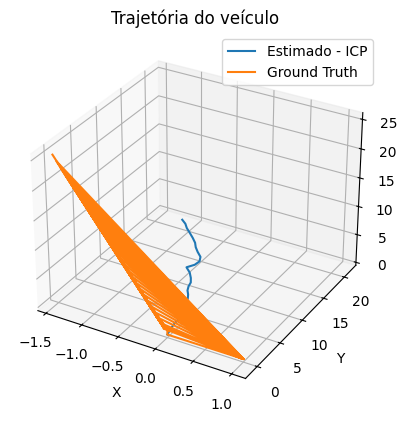

In [10]:
trajetoria, poses = trajetoria_estimada(scan_files)

ground_truth_path = "ground_truth.npy"
gt = np.load(ground_truth_path)
gt_xyz = gt[:, :3, 3]

plot_trajetoria(trajetoria, gt)

In [11]:
print("\nTransformação final estimada:")
print(poses[-1])

#shutil.rmtree(temp_dir)


Transformação final estimada:
[[ 9.98922591e-01 -4.63917172e-02  1.21032586e-03 -1.17780227e+00]
 [ 4.63762262e-02  9.98867158e-01  1.06605014e-02  2.12572667e+01]
 [-1.70351372e-03 -1.05928854e-02  9.99942443e-01  7.00911750e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


In [12]:
print("Variação ground-truth:")
print("x:", np.ptp(gt_xyz[:, 0]))
print("y:", np.ptp(gt_xyz[:, 1]))
print("z:", np.ptp(gt_xyz[:, 2]))

Variação ground-truth:
x: 1.436633
y: 0.8456208000000003
z: 25.59694
